In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [18]:
base_url = "https://raw.githubusercontent.com/hankroark/Turbofan-Engine-Degradation/master/CMAPSSData/"
url_train = f"{base_url}train_FD001.txt"
url_test  = f"{base_url}test_FD001.txt"
url_truth = f"{base_url}RUL_FD001.txt"

print("--- Actively Requesting NASA C-MAPSS Telemetry Tables From Mirror ---")

# Ingest data directly into your notebook memory space using whitespace separators
train_df = pd.read_csv(url_train, sep=r'\s+', header=None, names=col_names)
test_df  = pd.read_csv(url_test,  sep=r'\s+', header=None, names=col_names)
truth_df = pd.read_csv(url_truth, sep=r'\s+', header=None, names=['RUL_True'])

print("\n🚀 Data Loading Complete!")
print(f"  Train Set Matrix Shape : {train_df.shape} (Should show 20631 rows, 26 columns)")
print(f"  Test Set Matrix Shape  : {test_df.shape} (Should show 13096 rows, 26 columns)")
print(f"  True RUL Target Shape  : {truth_df.shape}   (Should show 100 rows, 1 column)")

--- Actively Requesting NASA C-MAPSS Telemetry Tables From Mirror ---

🚀 Data Loading Complete!
  Train Set Matrix Shape : (20631, 26) (Should show 20631 rows, 26 columns)
  Test Set Matrix Shape  : (13096, 26) (Should show 13096 rows, 26 columns)
  True RUL Target Shape  : (100, 1)   (Should show 100 rows, 1 column)


In [19]:
print("--- Step 2: Processing 2D Structural Grid ---")


# Find the final operational cycle reached by each engine asset individually
max_cycles = train_df.groupby('engine_id')['cycle'].max().reset_index().rename(columns={'cycle': 'max_cycle'})
train_df = pd.merge(train_df, max_cycles, on='engine_id')

# Calculate the continuous linear decay trajectory line
train_df['RUL_Linear'] = train_df['max_cycle'] - train_df['cycle']

# Bound the maximum target to a flat cap threshold of 125 cycles
train_df['RUL_Target'] = np.minimum(train_df['RUL_Linear'], 125)
train_df.drop(columns=['max_cycle', 'RUL_Linear'], inplace=True)

# 2. Drop constant flat-lined sensors carrying 0 mathematical variance
invalid_sensors = ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
features_to_scale = [col for col in setting_names + sensor_names if col not in invalid_sensors]

# 3. Apply MinMax Normalization to scale values to a unified [0, 1] range
scaler = MinMaxScaler()
train_df[features_to_scale] = scaler.fit_transform(train_df[features_to_scale])
test_df[features_to_scale] = scaler.transform(test_df[features_to_scale])

print(f" {train_df.shape}")

--- Step 2: Processing 2D Structural Grid ---
✅ 2D Preprocessing Complete! Features Shape: (20631, 27)


In [20]:
def create_3d_sliding_windows(df, window_size, feature_cols, target_col=None, is_test=False):
    X_data, y_data = [], []

    # Isolate engine asset IDs to keep separate asset timelines perfectly distinct
    for engine_id in df['engine_id'].unique():
        engine_subset = df[df['engine_id'] == engine_id]

        if is_test:
            # Test Evaluation requires only the absolute LATEST state window to predict the final single RUL step
            if len(engine_subset) >= window_size:
                window = engine_subset[feature_cols].values[-window_size:]
                X_data.append(window)
        else:
            feature_array = engine_subset[feature_cols].values
            target_array = engine_subset[target_col].values

            # Slide a window of size 30 along the engine's timeline duration
            for i in range(0, len(engine_subset) - window_size + 1):
                X_data.append(feature_array[i : i + window_size])
                # Always map the 30-cycle block to the target RUL of the absolute LATEST step in that sequence
                y_data.append(target_array[i + window_size - 1])

    return np.array(X_data), np.array(y_data) if not is_test else np.array(X_data)

WINDOW_SIZE = 30
X_train, y_train = create_3d_sliding_windows(train_df, WINDOW_SIZE, features_to_scale, target_col='RUL_Target')
X_test = create_3d_sliding_windows(test_df, WINDOW_SIZE, features_to_scale, is_test=True)

print(f"✅ 3D Reshaping Complete! Training Features Shape: {X_train.shape}")

✅ 3D Reshaping Complete! Training Features Shape: (17731, 30, 17)


In [21]:
model = Sequential([

    Conv1D(filters=32, kernel_size=3, activation='relu', padding='same', input_shape=(WINDOW_SIZE, len(features_to_scale))),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),


    LSTM(units=64, return_sequences=True),
    LSTM(units=32),
    Dropout(0.2),


    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 30, 32)         │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 15, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,457 (154.13 KB)

 Trainable params: 39,457 (154.13 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:

early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=64,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)
print("✅ Network Training Cycle Successfully Completed!")


--- Step 5: Commencing Training Loop ---
Epoch 1/40
236/236 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - loss: 5139.3706 - mae: 61.0342 - val_loss: 2725.7686 - val_mae: 45.5967
Epoch 2/40
236/236 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - loss: 1973.9441 - mae: 39.3409 - val_loss: 1797.3188 - val_mae: 38.0847
Epoch 3/40
236/236 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 1783.1960 - mae: 37.2758 - val_loss: 1789.3395 - val_mae: 37.8691
Epoch 4/40
236/236 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 1786.2040 - mae: 37.3290 - val_loss: 1788.0084 - val_mae: 37.7928
Epoch 5/40
236/236 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 1523.9825 - mae: 33.7478 - val_loss: 584.6359 - val_mae: 20.8714
Epoch 6/40
236/236 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - loss: 479.7590 - mae: 17.4813 - val_loss: 321.5670 - val_mae: 15.2130
Epoch 7/40
236/236 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - loss: 344.2444 - mae: 14.3297 - val_loss: 294.2190 - val_mae: 14.6009
Epoch 8/40
236/236 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 307.7651 - 

In [24]:
print("\n--- Step 6: Performing Inference & Prognostic Validation ---")


y_test_true = truth_df['RUL_True'].values
y_test_pred = model.predict(X_test).flatten()


y_test_pred = np.maximum(y_test_pred, 0)

# Custom Asymmetric NASA Loss Function
def compute_nasa_scoring(y_true, y_pred):
    distances = y_pred - y_true
    scores = []
    for d in distances:
        if d < 0:
            scores.append(np.exp(-d / 13.0) - 1.0) #
        else:
            scores.append(np.exp(d / 10.0) - 1.0)   #
    return np.sum(scores)

print("\n==============================================")
print(f"NASA Production Benchmark Score: {compute_nasa_scoring(y_test_true, y_test_pred):.2f}")
print(f"Mean Absolute Error (MAE): {np.mean(np.abs(y_test_pred - y_test_true)):.2f} flight cycles")
print(f"==============================================")


--- Step 6: Performing Inference & Prognostic Validation ---


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=('Tensor(shape=(32, 30, 17))', 'Tensor(shape=(32, 30, 17))')
  warnings.warn(msg)


1/4 ━━━━━━━━━━━━━━━━━━━━ 2s 778ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=('Tensor(shape=(None, 30, 17))', 'Tensor(shape=(None, 30, 17))')
  warnings.warn(msg)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step

NASA Production Benchmark Score: 430.75
Mean Absolute Error (MAE): 13.50 flight cycles



--- Step 7: Generating Performance Visualizations ---


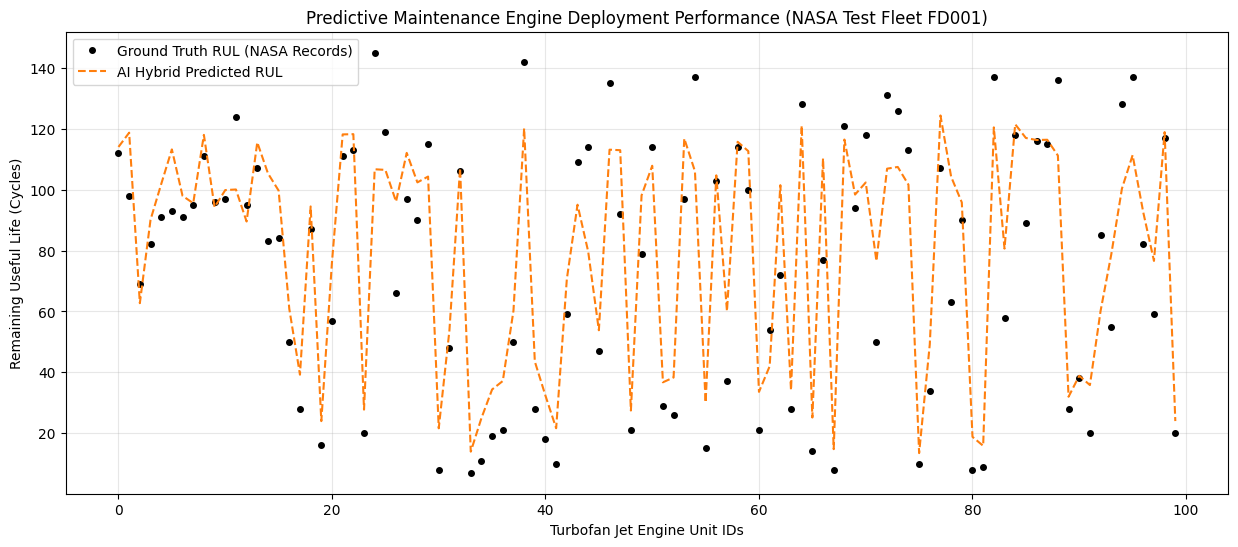

In [25]:
print("\n--- Step 7: Generating Performance Visualizations ---")

plt.figure(figsize=(15, 6))
plt.plot(y_test_true, label='Ground Truth RUL (NASA Records)', color='black', marker='o', markersize=4, linestyle='none')
plt.plot(y_test_pred, label='AI Hybrid Predicted RUL', color='#ff7f0e', linestyle='--', linewidth=1.5)
plt.title('Predictive Maintenance Engine Deployment Performance (NASA Test Fleet FD001)')
plt.ylabel('Remaining Useful Life (Cycles)')
plt.xlabel('Turbofan Jet Engine Unit IDs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

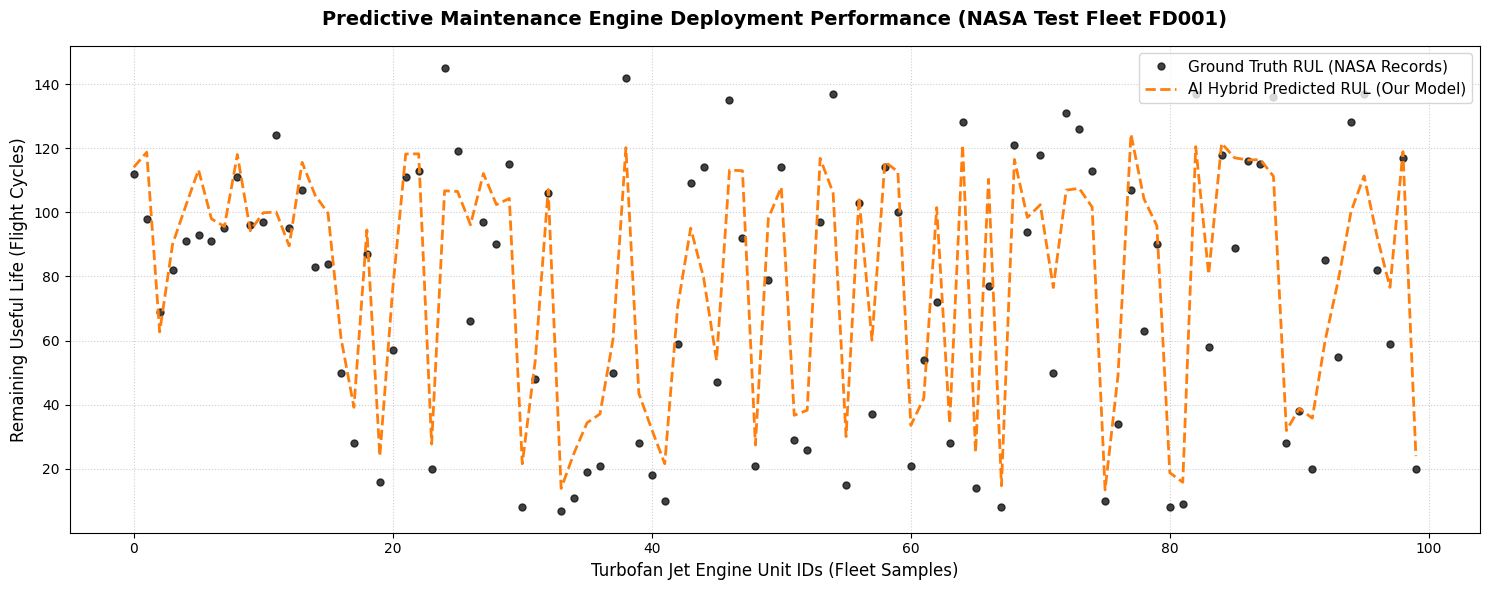

📁 Success! Look at your Colab left sidebar folder. 'predictive_maintenance_results.png' is ready to download!


In [27]:
import matplotlib.pyplot as plt

# Establish a professional, clean figure size for web display
plt.figure(figsize=(15, 6))

# Plot the real, known remaining flights as solid black marker points
plt.plot(y_test_true, label='Ground Truth RUL (NASA Records)', color='#111111', marker='o', markersize=5, linestyle='none', alpha=0.8)

# Plot your AI network's guesses as a sharp, tracking dashed line
plt.plot(y_test_pred, label='AI Hybrid Predicted RUL (Our Model)', color='#ff7f0e', linestyle='--', linewidth=2)

# Professional Chart Styling
plt.title('Predictive Maintenance Engine Deployment Performance (NASA Test Fleet FD001)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Remaining Useful Life (Flight Cycles)', fontsize=12)
plt.xlabel('Turbofan Jet Engine Unit IDs (Fleet Samples)', fontsize=12)
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

# Tighten the margins so it looks crisp
plt.tight_layout()

# CRITICAL: This line saves the chart directly into your Colab file explorer sidebar
plt.savefig('predictive_maintenance_results.png', dpi=300)

# Display the chart right here on your screen
plt.show()
print("📁 Success! Look at your Colab left sidebar folder. 'predictive_maintenance_results.png' is ready to download!")